# **1. Carga de librerías y lectura del conjunto de datos**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ad_viz_plotval_data.csv to ad_viz_plotval_data.csv


In [ ]:
import numpy as np     #Cálculos númericos y manejo de arreglos/matrices.
import pandas as pd    #Organizar , limpiar y analizar datos en forma de tablas .
import matplotlib.pyplot as plt  #Crear graficos
import seaborn as sns            # Crear gráficos estadísticos más elaborados y visualmente agradables .
%matplotlib inline

In [ ]:
df = pd.read_csv("ad_viz_plotval_data.csv")
df.head() #vemos los 5 primeros datos en el data frame

,Date,Source,Site ID,POC,Daily Max 8-hour Ozone Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,AQS Parameter Description,Method Code,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2022,AQS,60750005,1,0.029,ppm,27,San Francisco,17,100.0,...,Ozone,47,41860,"San Francisco-Oakland-Hayward, CA",6,California,75,San Francisco,37.765946,-122.399044
1,01/02/2022,AQS,60750005,1,0.029,ppm,27,San Francisco,17,100.0,...,Ozone,47,41860,"San Francisco-Oakland-Hayward, CA",6,California,75,San Francisco,37.765946,-122.399044
2,01/03/2022,AQS,60750005,1,0.032,ppm,30,San Francisco,17,100.0,...,Ozone,47,41860,"San Francisco-Oakland-Hayward, CA",6,California,75,San Francisco,37.765946,-122.399044
3,01/04/2022,AQS,60750005,1,0.032,ppm,30,San Francisco,17,100.0,...,Ozone,47,41860,"San Francisco-Oakland-Hayward, CA",6,California,75,San Francisco,37.765946,-122.399044
4,01/05/2022,AQS,60750005,1,0.025,ppm,23,San Francisco,17,100.0,...,Ozone,47,41860,"San Francisco-Oakland-Hayward, CA",6,California,75,San Francisco,37.765946,-122.399044


# **2. Exploración inicial del conjunto de datos**

In [ ]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355 entries, 0 to 354
Data columns (total 21 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Date                                  355 non-null    object 
 1   Source                                355 non-null    object 
 2   Site ID                               355 non-null    int64  
 3   POC                                   355 non-null    int64  
 4   Daily Max 8-hour Ozone Concentration  355 non-null    float64
 5   Units                                 355 non-null    object 
 6   Daily AQI Value                       355 non-null    int64  
 7   Local Site Name                       355 non-null    object 
 8   Daily Obs Count                       355 non-null    int64  
 9   Percent Complete                      355 non-null    float64
 10  AQS Parameter Code                    355 non-null    int64  
 11  AQS Parameter Descr

In [ ]:
df.describe().round(1)

,Site ID,POC,Daily Max 8-hour Ozone Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,State FIPS Code,County FIPS Code,Site Latitude,Site Longitude
count,355.0,355.0,355.0,355.0,355.0,355.0,355.0,355.0,355.0,355.0,355.0,355.0,355.0
mean,60750005.0,1.0,0.0,26.8,17.0,99.8,44201.0,47.0,41860.0,6.0,75.0,37.8,-122.4
std,0.0,0.0,0.0,7.3,0.3,1.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,60750005.0,1.0,0.0,8.0,13.0,76.0,44201.0,47.0,41860.0,6.0,75.0,37.8,-122.4
25%,60750005.0,1.0,0.0,21.0,17.0,100.0,44201.0,47.0,41860.0,6.0,75.0,37.8,-122.4
50%,60750005.0,1.0,0.0,27.0,17.0,100.0,44201.0,47.0,41860.0,6.0,75.0,37.8,-122.4
75%,60750005.0,1.0,0.0,32.0,17.0,100.0,44201.0,47.0,41860.0,6.0,75.0,37.8,-122.4
max,60750005.0,1.0,0.1,67.0,17.0,100.0,44201.0,47.0,41860.0,6.0,75.0,37.8,-122.4


In [ ]:
df.columns

Index(['Date', 'Source', 'Site ID', 'POC',
       'Daily Max 8-hour Ozone Concentration', 'Units', 'Daily AQI Value',
       'Local Site Name', 'Daily Obs Count', 'Percent Complete',
       'AQS Parameter Code', 'AQS Parameter Description', 'Method Code',
       'CBSA Code', 'CBSA Name', 'State FIPS Code', 'State',
       'County FIPS Code', 'County', 'Site Latitude', 'Site Longitude'],
      dtype='object')

**3. Exploración gráfica del AQI diario**

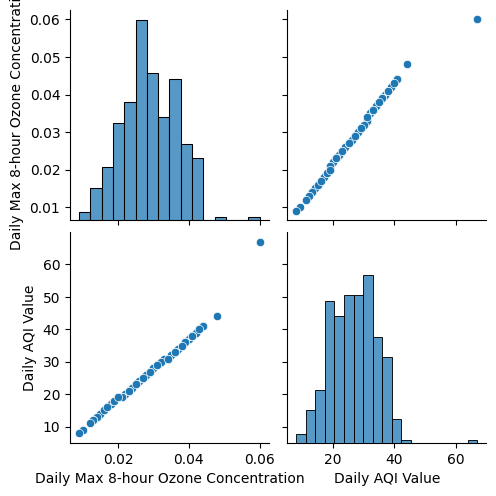

In [ ]:
sns.pairplot(df[['Daily Max 8-hour Ozone Concentration', 'Daily AQI Value']])

'\nHistograma: ¿Cómo se distribuyen los datos por intervalos?\n'

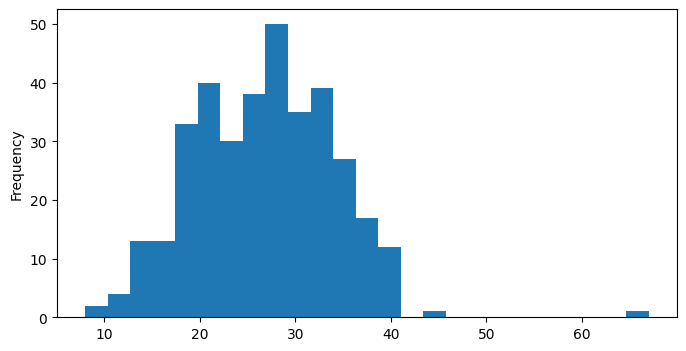

In [ ]:
df['Daily AQI Value'].plot.hist(bins=25, figsize=(8,4))
#histograma en 25 intervalos
'''
Histograma: ¿Cómo se distribuyen los datos por intervalos?
'''

#figsize(ancho,alto): tamaño de la figura

'\nDensidad: ¿Dónde están concentrados los datos?\n'

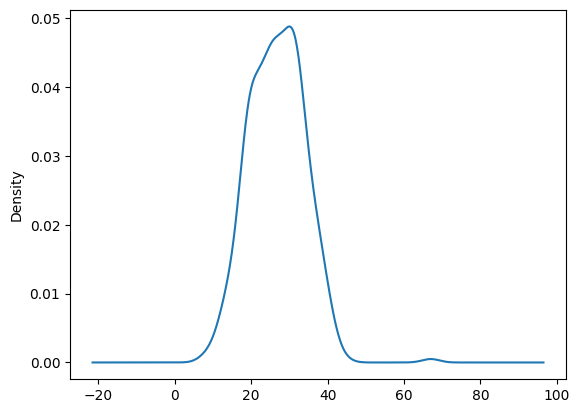

In [ ]:
df['Daily AQI Value'].plot.density()
'''
Densidad: ¿Dónde están concentrados los datos?
'''

### **4. DISTRIBUCIÓN DEL AQI (Matriz de correlación y Heatmap)**

In [ ]:
numeric_df = df[['Daily Max 8-hour Ozone Concentration', 'Daily AQI Value']]#seleccionamos solo las columnas numéricas que realmente varían
numeric_df.corr().round(4)#Cálculo de la correlación

,Daily Max 8-hour Ozone Concentration,Daily AQI Value
Daily Max 8-hour Ozone Concentration,1.0000,0.9958
Daily AQI Value,0.9958,1.0000


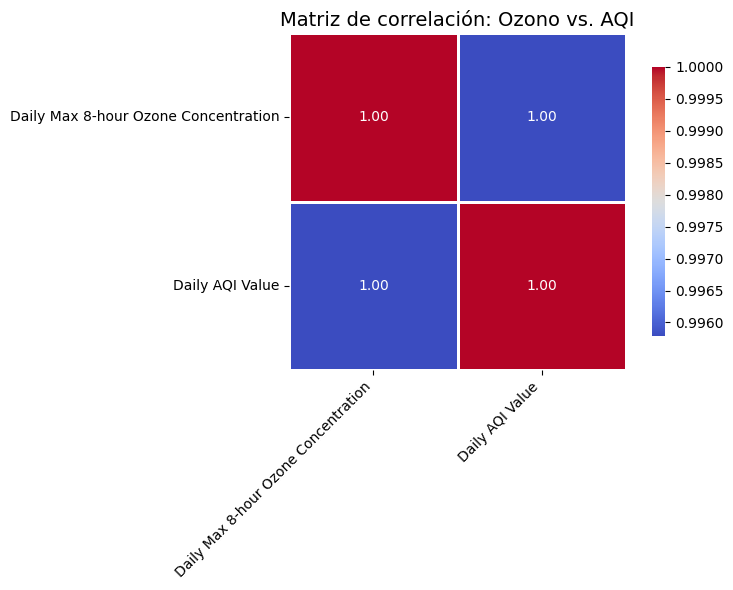

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=1, linecolor='white', square=True,
            cbar_kws={'shrink': 0.8})
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Matriz de correlación: Ozono vs. AQI", fontsize=14)
plt.tight_layout()
#Mapa de calor de correlaciones

# **5. Preparación de datos para el modelo predictivo**

In [ ]:
X = df[['Daily Max 8-hour Ozone Concentration']]   # variable independiente
Y = df['Daily AQI Value']                          # variable dependiente
X.head()

,Daily Max 8-hour Ozone Concentration
0,0.029
1,0.029
2,0.032
3,0.032
4,0.025


# **6. Entrenamiento del modelo de regresión lineal**

In [ ]:
from sklearn.model_selection import train_test_split
#divide datos en : entrenamiento y prueba

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=123)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics
#maching learning
#modelo: regresión lineal
#métricas: ¿qué tan buenas son las predicciones?

In [ ]:
lm = LinearRegression()

In [ ]:
lm.fit(X_train, Y_train)

LinearRegression()

In [ ]:
print("El termino de intersección del modelo lineal :", lm.intercept_)

El termino de intersección del modelo lineal : 0.15363442483852197


In [ ]:
print("Los coeficientes del modelo lineal :", lm.coef_)

Los coeficientes del modelo lineal : [920.37559675]


In [ ]:
cdf = pd.DataFrame(data=lm.coef_, index=X_train.columns, columns=["Coefficients"])
cdf

,Coefficients
Daily Max 8-hour Ozone Concentration,920.375597


## **7. Evaluación estadística del coeficiente**

In [ ]:
n = X_train.shape[0]
k = X_train.shape[1]
dfN = n - k
train_pred = lm.predict(X_train)

train_error = np.square(train_pred - Y_train)
sum_error = np.sum(train_error)

se = [0]*k
for i in range(k):
  r = (sum_error/dfN)
  r = r/np.sum(np.square(X_train[list(X_train.columns)[i]] - X_train[list(X_train.columns)[i]].mean()))
  se[i] = np.sqrt(r)

cdf['Standard Error'] = se
cdf['t-statistic'] = cdf['Coefficients']/cdf['Standard Error']
cdf

,Coefficients,Standard Error,t-statistic
Daily Max 8-hour Ozone Concentration,920.375597,2.40311,382.993542


# **8. Análisis visual de la variable respecto al AQI**

Text(0, 0.5, 'Daily AQI Value')

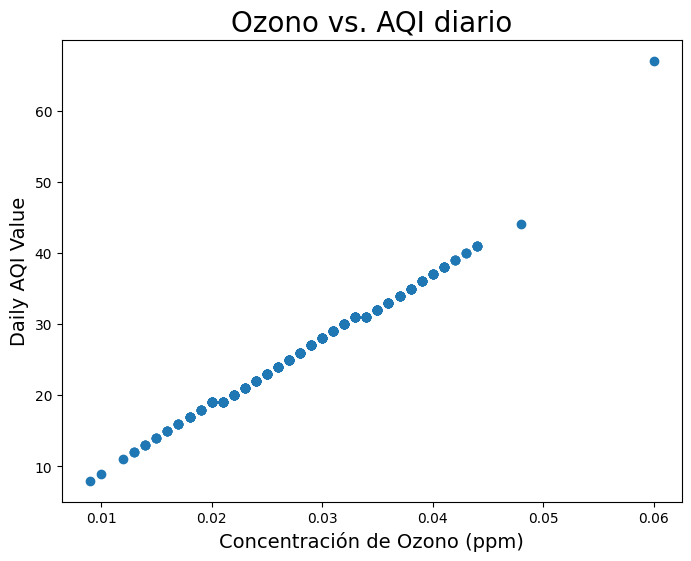

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df['Daily Max 8-hour Ozone Concentration'], df['Daily AQI Value'])
plt.title("Ozono vs. AQI diario", fontdict={'fontsize':20})
plt.xlabel("Concentración de Ozono (ppm)", fontsize=14)
plt.ylabel("Daily AQI Value", fontsize=14)

## **9. Comparación de valores reales y predichos**

In [ ]:
predictions = lm.predict(X_test)
print("Tipo del objeto predicho :", type(predictions))
print("Tamaño del objeto predicho :", predictions.shape)

Tipo del objeto predicho : <class 'numpy.ndarray'>
Tamaño del objeto predicho : (107,)


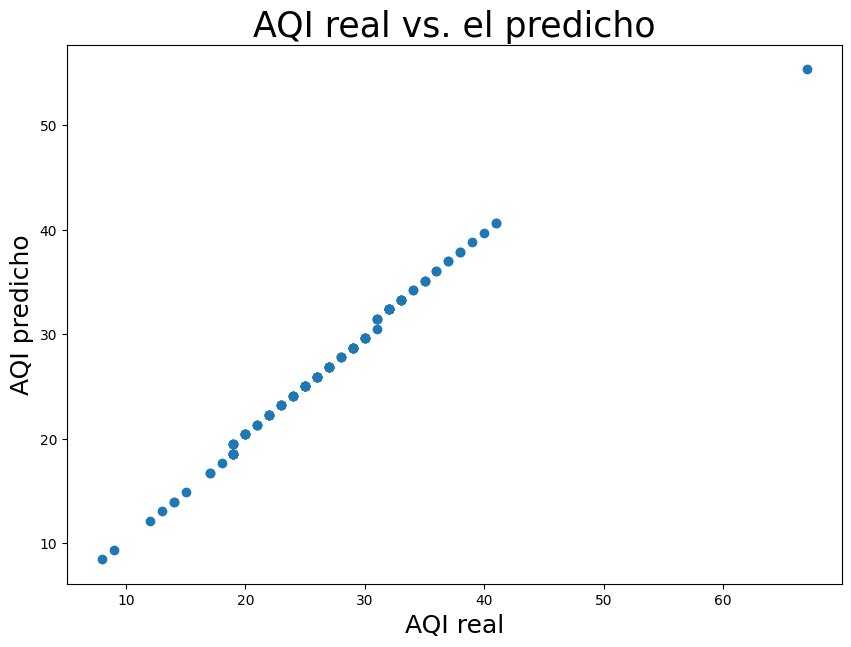

In [ ]:
#Diagrama de dispersión
plt.figure(figsize=(10,7))
plt.title("AQI real vs. el predicho", fontsize=25)
plt.xlabel("AQI real", fontsize=18)
plt.ylabel("AQI predicho", fontsize=18)
plt.scatter(Y_test, predictions)

# **10. Análisis de errores del modelo**

<Axes: title={'center': 'Histograma de residuos para verificar la normalidad'}, xlabel='Residuos', ylabel='Densidad del kernel'>

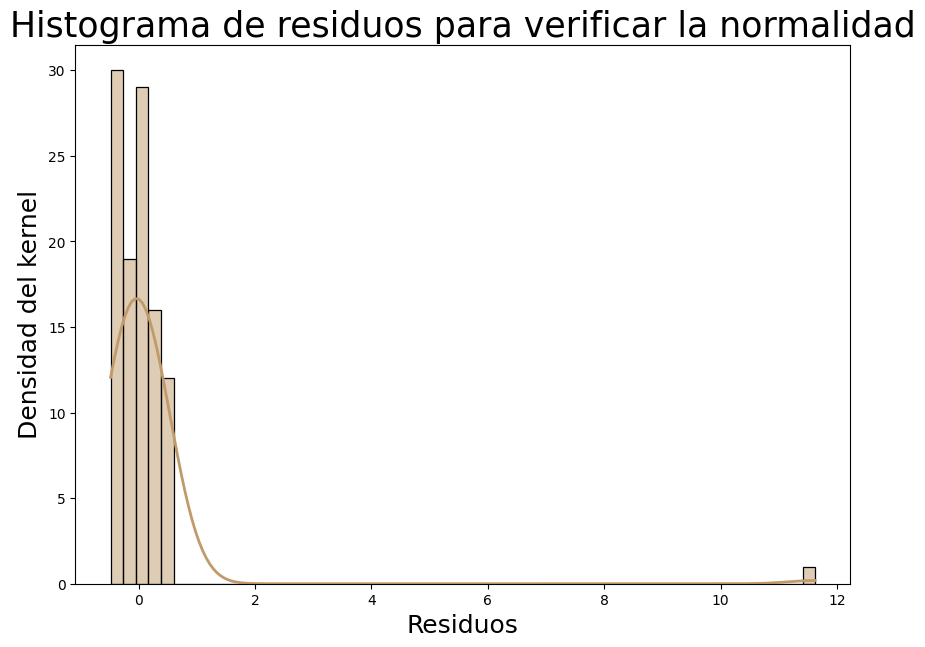

In [ ]:
plt.figure(figsize=(10, 7))
plt.title("Histograma de residuos para verificar la normalidad", fontsize=25)
plt.xlabel("Residuos", fontsize=18)
plt.ylabel("Densidad del kernel", fontsize=18)
sns.histplot((Y_test - predictions), kde=True, color="#c19a6b",
             line_kws={"color": "#ff7f0e", "linewidth": 2})

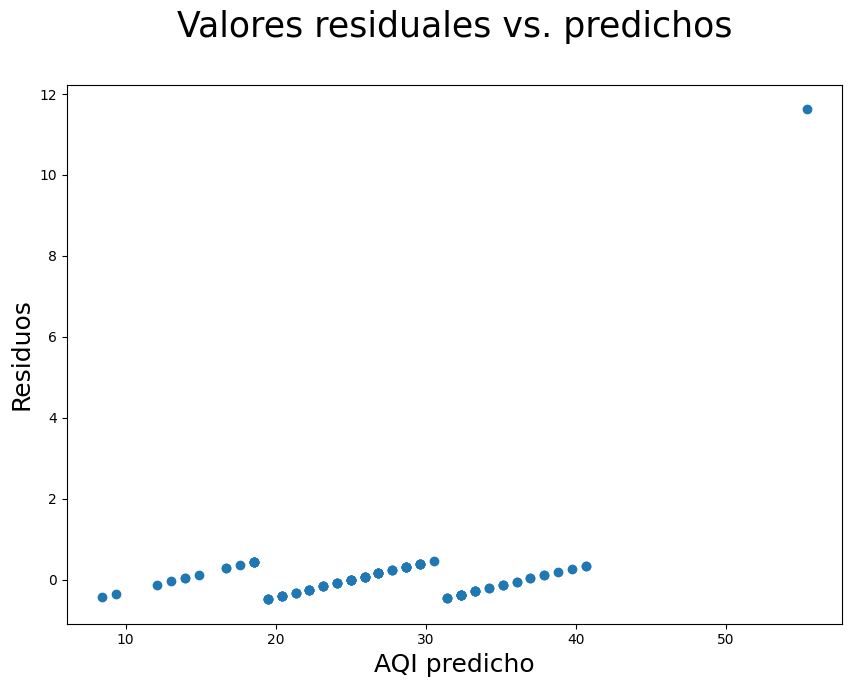

In [ ]:
# Diagrama de dispersión (Homoscedasticidad)
"""
La varianza de los errores es aprox. constante
a lo largo de las predicciones
"""

plt.figure(figsize=(10, 7))
plt.title("Valores residuales vs. predichos\n", fontsize=25)
plt.xlabel("AQI predicho", fontsize=18)
plt.ylabel("Residuos", fontsize=18)
plt.scatter(x=predictions, y=Y_test - predictions)

# **11. Generación de datos simulados para evaluación**

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import numpy as np

# Importar el método make_regression para generar muestras de datos artificiales
from sklearn.datasets import make_regression

n_samples = 100 # Número de muestras
n_features = 6 # Número de características
n_informative = 3 # Número de características informativas i.e. características reales que influyen en la salida

In [ ]:
X_sim, y_sim, coef_sim = make_regression(n_samples=n_samples, n_features=n_features, n_informative=n_informative,
                             random_state=20, shuffle=False, noise=20, coef=True)
# semilla aleatoria (reproducibilidad)
# que no se mezcle las características
# ruido aleatorio
# devuelve los coef.
print(coef_sim)

[78.58638696 97.72361019 52.30606265  0.          0.          0.        ]


In [ ]:
df_sim1 = pd.DataFrame(data=X_sim, columns=['X'+str(i) for i in range(1, n_features+1)])
df_sim2 = pd.DataFrame(data=y_sim, columns=['y'])
df_sim = pd.concat([df_sim1, df_sim2], axis=1)
df_sim.head(10)

,X1,X2,X3,X4,X5,X6,y
0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,109.512132
1,0.939469,-0.978481,0.503097,0.406414,0.323461,-0.493411,52.542242
2,-0.792017,-0.842368,-1.279503,0.245715,-0.044195,1.567633,-247.679018
3,1.051109,0.406368,-0.168646,-3.189703,1.120132,1.332778,98.678111
4,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-55.286890
5,-0.885493,-1.104579,0.932866,2.059838,-0.934938,-1.612990,-94.821349
6,0.527070,-1.551101,0.329613,-1.136527,-0.338491,0.320971,-75.940071
7,-0.602308,1.544728,0.647034,0.593217,0.438024,1.357789,139.247064
8,1.204511,1.351796,0.493437,-2.704365,-0.555186,0.001509,246.470338
9,0.857094,1.481144,-0.219661,1.503398,-1.482385,-0.856164,204.709196


## **12. Análisis gráfico de datos simulados**

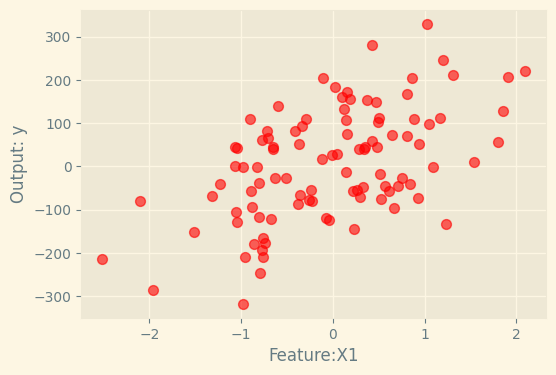

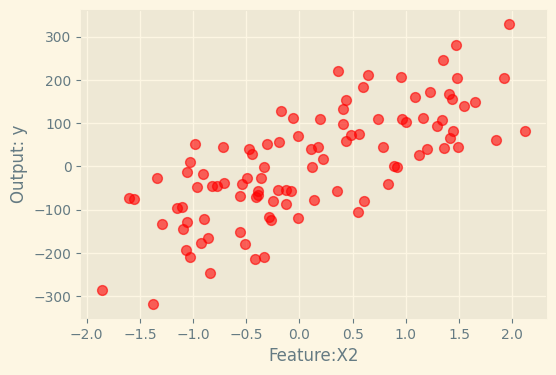

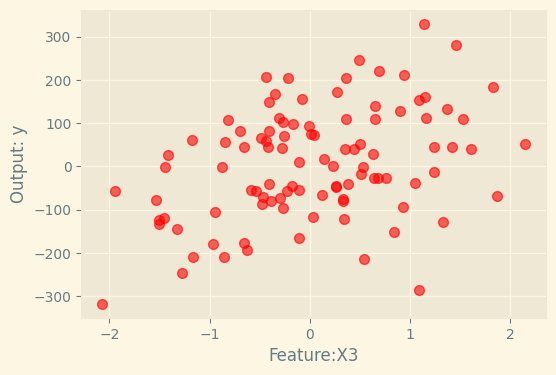

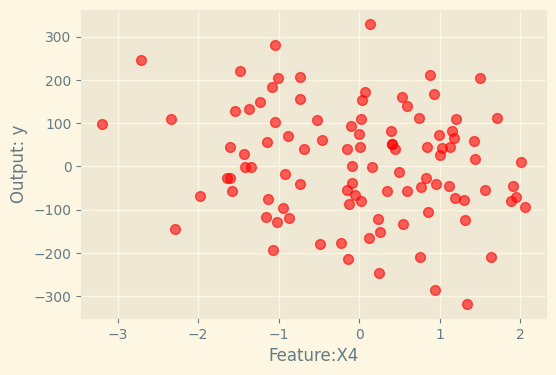

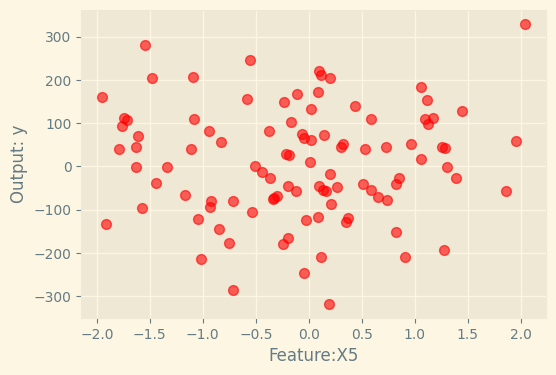

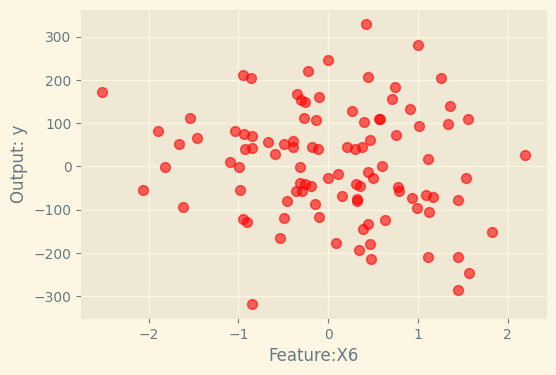

In [ ]:
with plt.style.context(('Solarize_Light2')):
    for i, col in enumerate(df_sim.columns[:-1]):
        plt.figure(figsize=(6, 4))
        plt.grid(True)
        plt.xlabel('Feature:' + col, fontsize=12)
        plt.ylabel('Output: y', fontsize=12)
        plt.scatter(df_sim[col], df_sim['y'], c='red', s=50, alpha=0.6)

## **13. Modelo de árbol de decisión**

Mean square error (MSE): 7931.574768958281


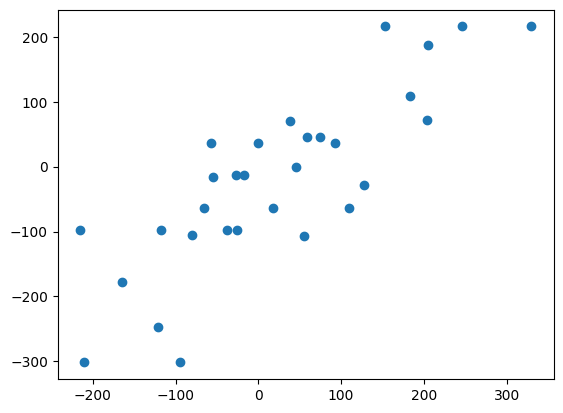

In [ ]:
from sklearn import tree
from sklearn.model_selection import train_test_split

X_train_sim, X_test_sim, y_train_sim, y_test_sim = train_test_split(
    X_sim, y_sim, test_size=0.3, random_state=123
)

# Creación del modelo
tree_model = tree.DecisionTreeRegressor(max_depth=5, random_state=10)
#                                        niveles de decisión
tree_model.fit(X_train_sim, y_train_sim)

from sklearn import metrics

# Hacemos predicciones
test_pred_sim = tree_model.predict(X_test_sim)
plt.scatter(x=y_test_sim, y=test_pred_sim) # real vs dicho
print("Mean square error (MSE):", metrics.mean_squared_error(y_test_sim, test_pred_sim))
# Error cuadrático medio

# **14. Importancia de variables del árbol**

Importancia relativa de las características:  [0.26900246 0.53730467 0.11075698 0.03758107 0.01219288 0.03316193]


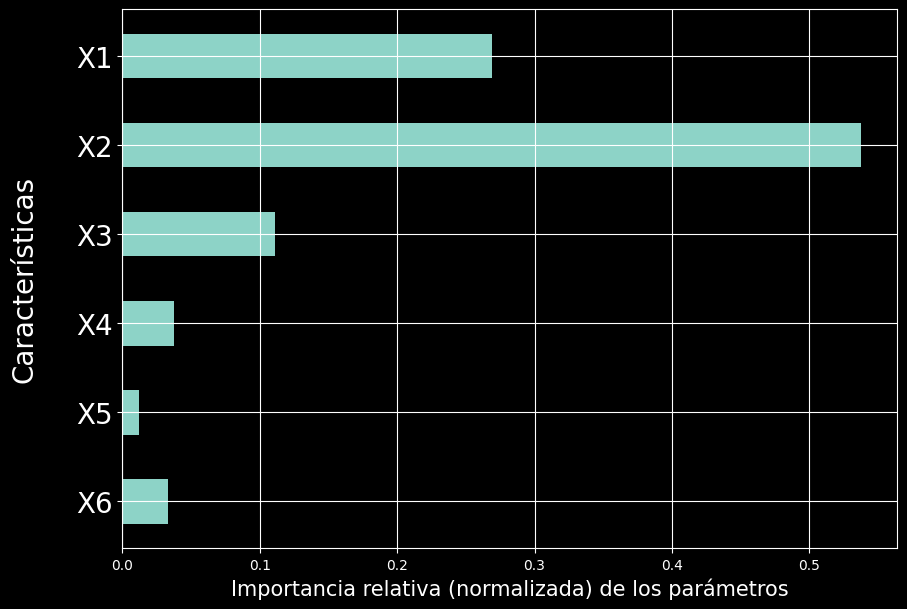

In [ ]:
print("Importancia relativa de las características: ", tree_model.feature_importances_)
with plt.style.context('dark_background'):
    plt.figure(figsize=(10, 7))
    plt.grid(True)
    plt.yticks(range(n_features+1, 1, -1), df_sim.columns[:-1], fontsize=20)
    plt.xlabel("Importancia relativa (normalizada) de los parámetros", fontsize=15)
    plt.ylabel("Características\n", fontsize=20)
    plt.barh(range(n_features+1, 1, -1), width=tree_model.feature_importances_, height=0.5)

# **15. Validación mediante modelo estadístico OLS**

In [ ]:
import statsmodels.api as sm

Xs = sm.add_constant(X_sim)
stat_model = sm.OLS(y_sim, Xs)
stat_result = stat_model.fit()
print(stat_result.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     628.6
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           5.97e-73
Time:                        20:55:37   Log-Likelihood:                -440.25
No. Observations:                 100   AIC:                             894.5
Df Residuals:                      93   BIC:                             912.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.8565      2.087     -1.848      0.0